In [81]:
from idun_guardian_sdk import GuardianClient, FileTypes
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np

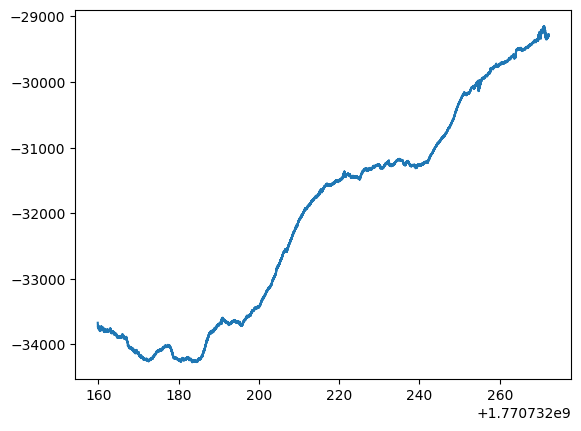

In [82]:
data = pd.read_csv('eeg_1770732156922.csv')
dt = np.median(np.diff(data['timestamp']))
fs = 1 / dt
plt.plot(data['timestamp'], data['ch1'])

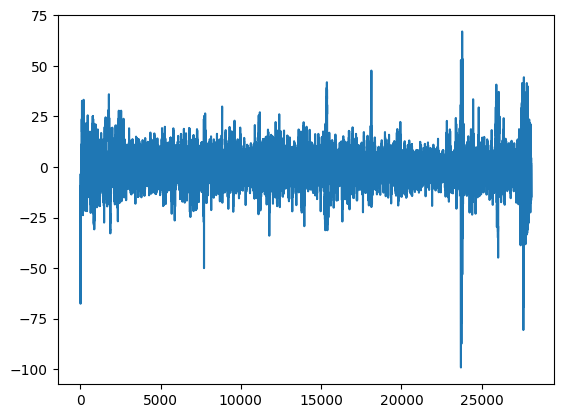

In [83]:
sos_notch = signal.iirdesign(
    wp=[46, 54], ws=[48, 52],
    gpass=1, gstop=60,
    ftype="cheby2", output="sos", fs=fs
)

sos_hp = signal.iirdesign(
    wp=1, ws=0.5, 
    gpass=1, gstop=40, 
    analog=False, ftype="butter", output="sos", fs=fs)

data_filt = signal.sosfiltfilt(sos_notch, data['ch1'])
data_filt = signal.sosfiltfilt(sos_hp, data_filt)
plt.plot(data_filt)

In [97]:
def epoch_signal(x, fs, epoch_sec=2.0):
    L = int(epoch_sec * fs)
    n_epochs = len(x) // L
    x = x[:n_epochs * L]
    return x.reshape(n_epochs, L)

def mad(a):
    med = np.median(a)
    return np.median(np.abs(a - med)) + 1e-12

epochs = epoch_signal(data_filt, fs, epoch_sec=2.0)

# metrics per epoch
ptp = np.ptp(epochs, axis=1)
rms = np.sqrt(np.mean(epochs**2, axis=1))
dmax = np.max(np.abs(np.diff(epochs, axis=1)), axis=1)

# robust thresholds: median + k*MAD
def robust_thresh(v, k=6.0):
    return np.median(v) + k * mad(v)

ptp_th = robust_thresh(ptp, k=6)
rms_th = robust_thresh(rms, k=6)
dmax_th = robust_thresh(dmax, k=6)

good = (ptp < ptp_th) & (rms < rms_th) & (dmax < dmax_th)

epochs_good = epochs[good]
print(f"Kept {good.mean()*100:.1f}% of epochs ({good.sum()}/{len(good)})")

Kept 87.5% of epochs (49/56)


In [109]:
# FFT per epoch and average power
P = []
for e in epochs_good:
    E = np.fft.rfft(e * np.hanning(len(e)))
    P.append(np.abs(E)**2)

P_mean = np.mean(P, axis=0)
freqs = np.fft.rfftfreq(len(epochs_good[0]), d=1/fs)

In [110]:
# FFT per epoch and average power using scipy.signal.welch
P_welch = []
for e in epochs_good:
    freqs_welch, E_welch = signal.welch(e, fs=fs, nperseg=len(e))
    P_welch.append(np.abs(E_welch)**2)

P_mean_welch = np.mean(P_welch, axis=0)

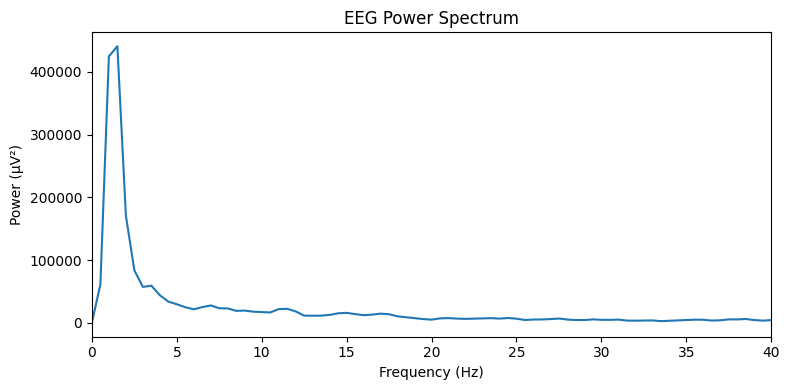

In [111]:
plt.figure(figsize=(8, 4))
plt.plot(freqs, P_mean)
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²)")
plt.title("EEG Power Spectrum")
plt.tight_layout()
plt.show()

In [112]:
def band_power(freqs, power, fmin, fmax):
    idx = np.logical_and(freqs >= fmin, freqs < fmax)
    df = freqs[1] - freqs[0]
    return np.sum(power[idx]) * df


delta = band_power(freqs, P_mean, 0.5, 4)
theta = band_power(freqs, P_mean, 4, 8)
alpha = band_power(freqs, P_mean, 8, 13)
beta  = band_power(freqs, P_mean, 13, 30)

total = delta + theta + alpha + beta

print("Relative power:")
print(f"Delta: {delta/total:.2%}")
print(f"Theta: {theta/total:.2%}")
print(f"Alpha: {alpha/total:.2%}")
print(f"Beta:  {beta/total:.2%}")

Relative power:
Delta: 64.63%
Theta: 11.48%
Alpha: 9.34%
Beta:  14.55%


In [113]:
def band_power(freqs, power, fmin, fmax):
    idx = np.logical_and(freqs >= fmin, freqs < fmax)
    df = freqs[1] - freqs[0]
    return np.sum(power[idx]) * df


delta = band_power(freqs_welch, P_mean_welch, 0.5, 4)
theta = band_power(freqs, P_mean_welch, 4, 8)
alpha = band_power(freqs, P_mean_welch, 8, 13)
beta  = band_power(freqs, P_mean_welch, 13, 30)

total = delta + theta + alpha + beta

print("Relative power with welch:")
print(f"Delta: {delta/total:.2%}")
print(f"Theta: {theta/total:.2%}")
print(f"Alpha: {alpha/total:.2%}")
print(f"Beta:  {beta/total:.2%}")

Relative power with welch:
Delta: 97.57%
Theta: 1.25%
Alpha: 0.65%
Beta:  0.53%
